In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df_t = pd.read_csv("parsely_daily_expanded.csv")
df_init = pd.read_csv(
    "posts-export-by-page-views-Feb-01-2025-Mar-05-2026-Masthead-Maine.csv"
)
df_t.head(20)

,date,url,title,author,section,tags,pub_date,word_count,views,recirculation_rate
0,2025-02-01,https://www.pressherald.com/2025/02/01/newly-h...,Newly hired Kennebunk High School theater teac...,Sydney Richelieu,Southern Maine Weeklies,"arundel maine, crime, kennebunk maine, kennebu...",2025-02-01T19:15:54,467,5770,0.113692
1,2025-02-01,https://www.pressherald.com/2025/02/01/how-muc...,How much snow fell in Maine on Friday and Satu...,Alex McCann,News,"local & state, maine weather, parsely_smart:ia...",2025-02-01T16:23:06,140,5638,0.097907
2,2025-02-01,https://www.pressherald.com/2025/01/30/lewisto...,"Lewiston private school sues state, family ove...",Riley Board,Lewiston-Auburn,"disabilities, lewiston maine, lewiston school ...",2025-01-30T21:10:48,1202,4423,0.036175
3,2025-02-01,https://www.pressherald.com/2025/02/02/maines-...,Maine’s Amy Allen wins songwriter of the year ...,Aimsel Ponti,Life & Culture,"amy allen, arts & entertainment, awards, local...",2025-02-03T04:54:19,590,3308,0.043229
4,2025-02-01,https://www.pressherald.com/2025/02/01/maines-...,Maine’s first sports betting parlor pauses wag...,Katie Langley,Business,"business, local & state, news, oddfellahs, par...",2025-02-01T20:17:49,335,3288,0.097019
5,2025-02-01,https://www.pressherald.com/2025/01/29/teenage...,Teenager detained by ICE in Massachusetts held...,Daniel Kool,News,"cops & courts, cumberland county jail, immigra...",2025-01-29T23:11:10,804,3125,0.036160
6,2025-02-01,https://www.pressherald.com/2025/02/02/our-vie...,Our View: Maine in no position to shrug at ‘na...,The Editorial Board,Opinion,"editorials, opinion, parsely_smart:entity:Read...",2025-02-02T09:00:00,218,2814,0.104122
7,2025-02-01,https://www.pressherald.com/2025/01/31/automak...,Automakers seek to overturn Maine’s ‘right to ...,Hannah LaClaire,Business,"auto industry, business, court, federal court,...",2025-01-31T18:25:41,745,2440,0.045902
8,2025-02-01,https://www.pressherald.com/2025/01/30/6-up-an...,6 up-and-coming Greater Portland chefs to watch,Tim Cebula,Food,"food, local & state, maine restaurants, parsel...",2025-01-30T09:00:27,3682,2258,0.114703
9,2025-02-01,https://www.pressherald.com/2025/02/01/poll-sh...,Gorham Connector gets more opposition than sup...,Kelley Bouchard,Business,"business, gorham connector, local & state, mai...",2025-02-01T09:00:04,1059,2249,0.170743


In [4]:
df_init.columns
df_init.shape
df_init.head(20)

,Apikey,URL,Title,Publish date,Authors,Section,Tags,Sort (Views),Visitors,Views,...,Channel vis.,Website views,AMP views,Fb instant views,Post id,Views source,Views syndicated,Views by Site,High-Level Smart Tags,Low-Level Smart Tags
0,pressherald.com,https://www.pressherald.com,The Portland Press Herald,NaN,Staff,Uncategorized,NaN,13604769,1188026,13604769,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,centralmaine.com,https://www.centralmaine.com,Kennebec Journal and Morning Sentinel,NaN,Staff,Uncategorized,NaN,4571551,453052,4571551,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Law, Gov’t & Politics,Legal Issues",NaN
2,pressherald.com,http://www.pressherald.com/obituaries/,Obituaries,NaN,Staff,Uncategorized,NaN,3465736,410059,3465736,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sunjournal.com,https://www.sunjournal.com,Lewiston Sun Journal,NaN,Staff,Uncategorized,NaN,3436858,367361,3436858,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,centralmaine.com,https://www.centralmaine.com/obituaries/,Obituaries,NaN,Staff,Uncategorized,NaN,3284383,275492,3284383,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,sunjournal.com,https://www.sunjournal.com/obituaries/,Obituaries,NaN,Staff,Uncategorized,NaN,2366996,208272,2366996,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,pressherald.com,http://www.pressherald.com/obituaries/page/2/,Obituaries,NaN,Staff,Uncategorized,NaN,1416276,220111,1416276,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,pressherald.com,http://www.pressherald.com/epaper/,ePaper,NaN,Staff,Uncategorized,NaN,1391123,163838,1391123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Arundel, Maine,Cape Elizabeth, Maine,Falmouth,..."
8,sunjournal.com,https://www.sunjournal.com/epaper/,ePaper,NaN,Staff,Uncategorized,NaN,691526,63721,691526,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,centralmaine.com,https://www.centralmaine.com/obituaries/page/2/,Obituaries,NaN,Staff,Uncategorized,NaN,691483,115917,691483,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Parsely daily expanded

In [5]:
df_t["pub_dateonly"] = pd.to_datetime(df_t["pub_date"]).dt.strftime("%Y-%m-%d")
df_t["pub_timeonly"] = pd.to_datetime(df_t["pub_date"]).dt.strftime("%H:%M:%S")

In [6]:
# Unique days vs total rows
df_t["pub_dateonly"].nunique() / df_t.shape[0]

0.008246898263027295

In [7]:
# Rows per day
rows_per_day = df_t.groupby("pub_dateonly").size()
rows_per_day

pub_dateonly
1809-08-10      2
1900-03-17      2
1969-12-31     87
1994-03-31     15
1994-04-17     17
             ... 
2026-03-07    153
2026-03-08    178
2026-03-09     88
2026-03-10     49
2026-03-11      9
Length: 6647, dtype: int64

In [8]:
unique_urls = df_t["url"].unique()
print(len(unique_urls))
print(len(unique_urls)/df_t.shape[0])

88264
0.10950868486352357


In [13]:
df_init["Views by Site"].unique()

array([nan, 'pressherald.com:108059,sunjournal.com:1816',
       'centralmaine.com:27,pressherald.com:90820,sunjournal.com:115',
       ..., 'centralmaine.com:72,pressherald.com:148,sunjournal.com:522',
       'pressherald.com:741',
       'centralmaine.com:1,pressherald.com:740,sunjournal.com:0'],
      shape=(7729,), dtype=object)

In [9]:
# Unique articles
article_per_day = df_t.groupby("pub_dateonly")["url"].nunique()
article_per_day

pub_dateonly
1809-08-10     1
1900-03-17     1
1969-12-31    25
1994-03-31     1
1994-04-17     1
              ..
2026-03-07    31
2026-03-08    46
2026-03-09    44
2026-03-10    45
2026-03-11     9
Name: url, Length: 6647, dtype: int64

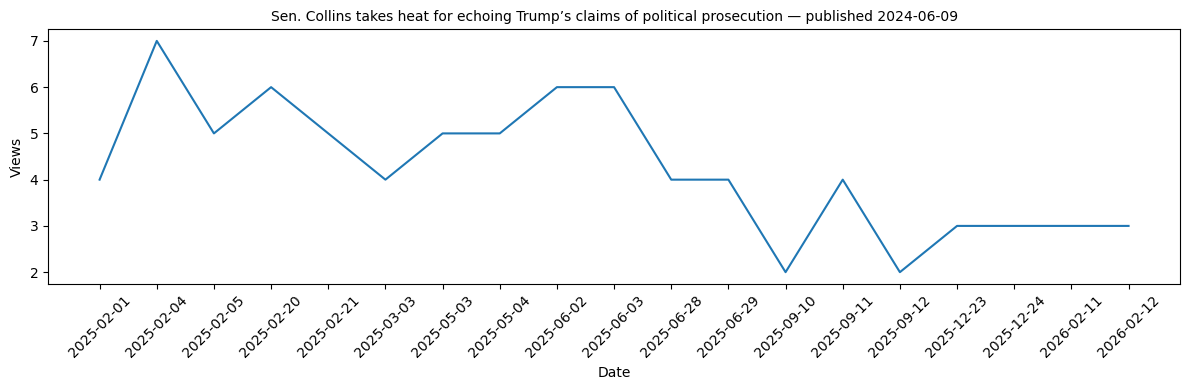

In [10]:
url = unique_urls[1000]
one = df_t[df_t["url"] == url].sort_values("date")
row = one.iloc[0]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one["date"], one["views"])
ax.tick_params(axis="x", rotation=45)
ax.set_title(f"{row['title']} — published {row['pub_dateonly']}", fontsize=10)
ax.set_xlabel("Date")
ax.set_ylabel("Views")
plt.tight_layout()
plt.show()